In [43]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [44]:
url="https://gist.githubusercontent.com/semicolonSimp/c0c6d036efa489d9c896c8851c3b3de7/raw/c9446e0d053dd6c6fd0988eb9cb498f8814d3ad8/Filename:%2520loan_approval_data.csv"
df = pd.read_csv(url)

In [45]:
df.head()
df.info()
df.isnull().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000
mean,500.329474,10821.730526,5118.503158,40.349474,1.489474,673.463158,1.885263,0.351516,9664.657895,24592.685263,20577.812632,48.618947
std,288.155619,5150.599062,2868.520119,10.939819,1.119515,72.645640,1.402427,0.144394,5928.969744,14116.344244,11279.973566,23.295691
min,1.000000,2016.000000,8.000000,21.000000,0.000000,550.000000,0.000000,0.100000,80.000000,73.000000,1047.000000,12.000000
25%,252.250000,6340.000000,2682.000000,31.000000,0.250000,610.250000,1.000000,0.220000,4388.000000,12425.000000,10969.000000,24.000000
50%,501.500000,10893.500000,5039.000000,41.000000,1.000000,671.000000,2.000000,0.350000,9338.500000,24175.000000,20782.000000,48.000000
75%,750.750000,15229.000000,7687.500000,50.000000,2.750000,737.750000,3.000000,0.480000,14852.000000,36222.750000,30054.000000,72.000000
max,1000.000000,19953.000000,9989.000000,59.000000,3.000000,799.000000,4.000000,0.600000,19959.000000,49871.000000,39916.000000,84.000000


# Handle Missing Values

In [46]:
categorical_cols = df.select_dtypes(include=["object"]).columns
numerical_cols = df.select_dtypes(include=["number"]).columns

In [47]:
from sklearn.impute import SimpleImputer

num_imp = SimpleImputer(strategy="mean")
df[numerical_cols] = num_imp.fit_transform(df[numerical_cols])

In [48]:
cat_imp = SimpleImputer(strategy="most_frequent")
df[categorical_cols] = cat_imp.fit_transform(df[categorical_cols])

In [49]:
df.head()
df.isnull().sum()

,0
Applicant_ID,0
Applicant_Income,0
Coapplicant_Income,0
Employment_Status,0
Age,0
Marital_Status,0
Dependents,0
Credit_Score,0
Existing_Loans,0
DTI_Ratio,0


# EDA - exploratory data analysis

Text(0.5, 1.0, 'Is Loan approved or not?')

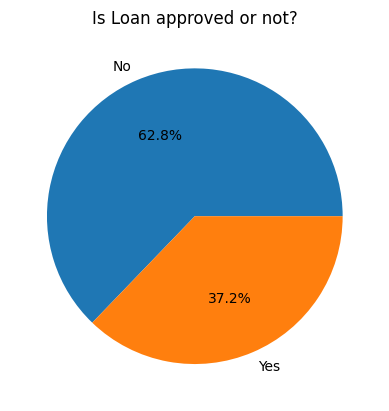

In [50]:
# how balanced our classes are?

classes_count = df["Loan_Approved"].value_counts()

plt.pie(classes_count, labels=["No", "Yes"], autopct="%1.1f%%")
plt.title("Is Loan approved or not?")

[Text(0, 0, '705'), Text(0, 0, '295')]

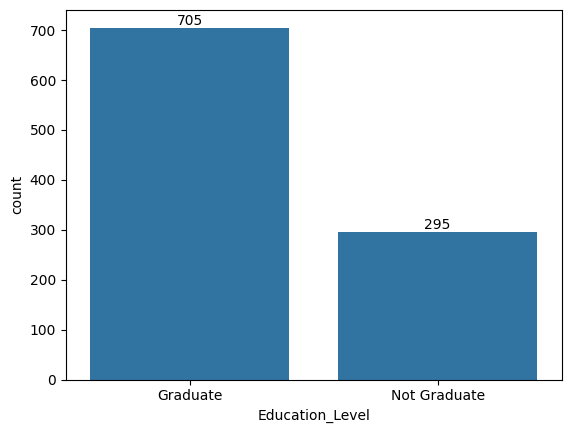

In [51]:
# analyze categories

# gender_cnt = df["Gender"].value_counts()
# ax = sns.barplot(gender_cnt)
# ax.bar_label(ax.containers[0])

edu_cnt = df["Education_Level"].value_counts()
ax = sns.barplot(edu_cnt)
ax.bar_label(ax.containers[0])

<Axes: xlabel='Applicant_Income', ylabel='Count'>

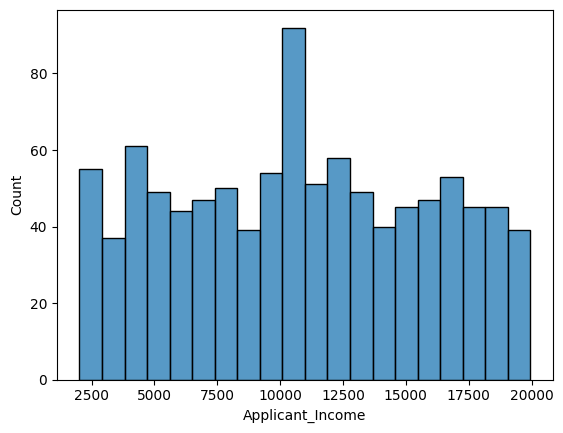

In [52]:
# analyze income

sns.histplot(
    data = df,
    x = "Applicant_Income",
    bins=20
)

<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

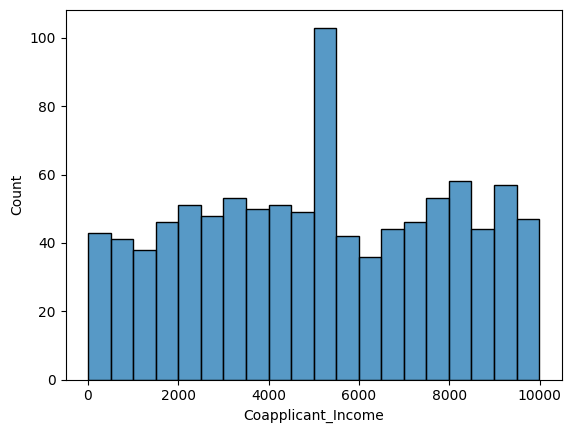

In [53]:
sns.histplot(
    data = df,
    x = "Coapplicant_Income",
    bins=20
)

<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

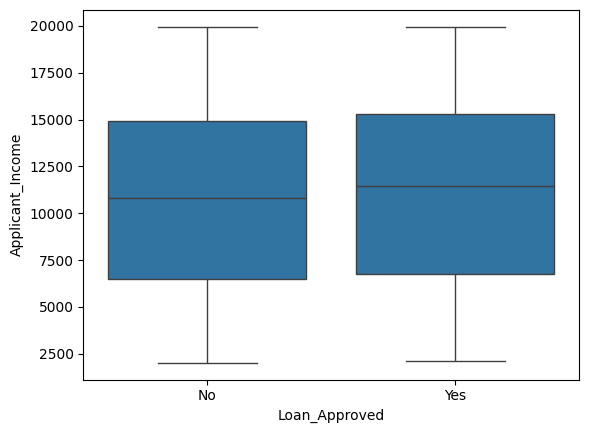

In [54]:
# outliers - box plots

sns.boxplot(
    data=df,
    x="Loan_Approved",
    y="Applicant_Income"
)

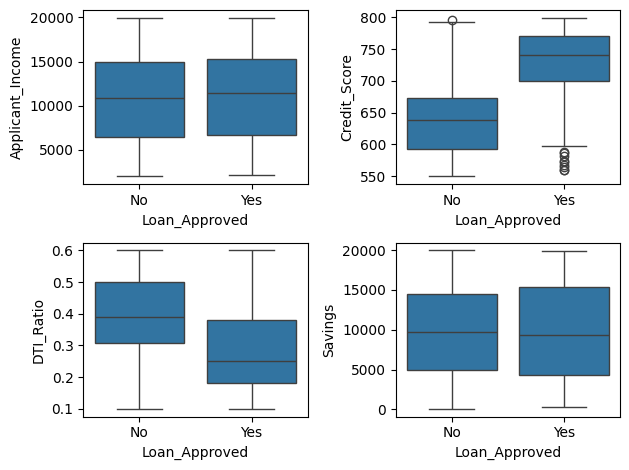

In [55]:
fig, axes = plt.subplots(2, 2)

sns.boxplot(ax=axes[0, 0], data=df, x="Loan_Approved",y="Applicant_Income")
sns.boxplot(ax=axes[0, 1], data=df, x="Loan_Approved",y="Credit_Score")
sns.boxplot(ax=axes[1, 0], data=df, x="Loan_Approved",y="DTI_Ratio")
sns.boxplot(ax=axes[1, 1], data=df, x="Loan_Approved",y="Savings")

plt.tight_layout()

<Axes: xlabel='Credit_Score', ylabel='Count'>

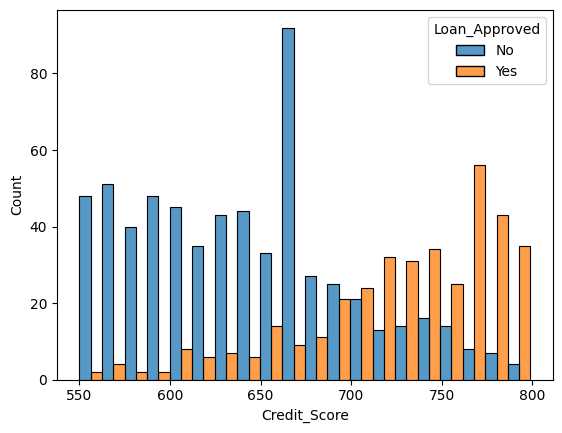

In [56]:
# Credit Score with Loan Approved

sns.histplot(
    data=df,
    x="Credit_Score",
    hue="Loan_Approved",
    bins=20,
    multiple="dodge"
)

<Axes: xlabel='Applicant_Income', ylabel='Count'>

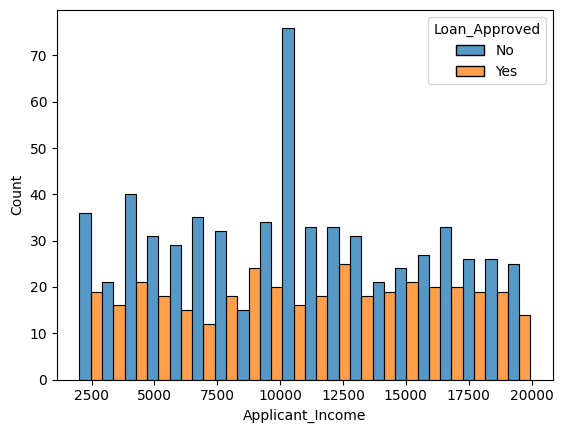

In [57]:
sns.histplot(
    data=df,
    x="Applicant_Income",
    hue="Loan_Approved",
    bins=20,
    multiple="dodge"
)

In [58]:
# Remove Applicant Id
df = df.drop("Applicant_ID", axis=1)

In [59]:
df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,9761.0,9231.0,Retired,29.0,Married,2.0,742.0,1.0,0.24,85.0,31886.0,9528.0,36.0,Education,Urban,Graduate,Male,Private,No
1,12993.0,4943.0,Self-employed,23.0,Married,1.0,646.0,0.0,0.47,1486.0,19255.0,10191.0,84.0,Personal,Rural,Not Graduate,Male,Business,No
2,14425.0,7377.0,Salaried,49.0,Married,3.0,744.0,2.0,0.14,2459.0,41658.0,35104.0,36.0,Education,Urban,Graduate,Male,MNC,Yes
3,6340.0,4525.0,Self-employed,53.0,Single,3.0,670.0,4.0,0.35,18441.0,20868.0,39130.0,60.0,Business,Rural,Graduate,Male,Unemployed,No
4,10889.0,5987.0,Unemployed,56.0,Married,0.0,639.0,0.0,0.39,345.0,1782.0,28951.0,12.0,Car,Rural,Graduate,Male,Unemployed,No


# Encoding

In [60]:
df.head()
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_Income    1000 non-null   float64
 1   Coapplicant_Income  1000 non-null   float64
 2   Employment_Status   1000 non-null   object 
 3   Age                 1000 non-null   float64
 4   Marital_Status      1000 non-null   object 
 5   Dependents          1000 non-null   float64
 6   Credit_Score        1000 non-null   float64
 7   Existing_Loans      1000 non-null   float64
 8   DTI_Ratio           1000 non-null   float64
 9   Savings             1000 non-null   float64
 10  Collateral_Value    1000 non-null   float64
 11  Loan_Amount         1000 non-null   float64
 12  Loan_Term           1000 non-null   float64
 13  Loan_Purpose        1000 non-null   object 
 14  Property_Area       1000 non-null   object 
 15  Education_Level     1000 non-null   object 
 16  Gender 

In [61]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

le = LabelEncoder()
df["Education_Level"] = le.fit_transform(df["Education_Level"])
df["Loan_Approved"] = le.fit_transform(df["Loan_Approved"])


In [62]:
df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,9761.0,9231.0,Retired,29.0,Married,2.0,742.0,1.0,0.24,85.0,31886.0,9528.0,36.0,Education,Urban,0,Male,Private,0
1,12993.0,4943.0,Self-employed,23.0,Married,1.0,646.0,0.0,0.47,1486.0,19255.0,10191.0,84.0,Personal,Rural,1,Male,Business,0
2,14425.0,7377.0,Salaried,49.0,Married,3.0,744.0,2.0,0.14,2459.0,41658.0,35104.0,36.0,Education,Urban,0,Male,MNC,1
3,6340.0,4525.0,Self-employed,53.0,Single,3.0,670.0,4.0,0.35,18441.0,20868.0,39130.0,60.0,Business,Rural,0,Male,Unemployed,0
4,10889.0,5987.0,Unemployed,56.0,Married,0.0,639.0,0.0,0.39,345.0,1782.0,28951.0,12.0,Car,Rural,0,Male,Unemployed,0


In [63]:
cols = ["Employment_Status", "Marital_Status", "Loan_Purpose", "Property_Area", "Gender", "Employer_Category"]

ohe = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")

encoded = ohe.fit_transform(df[cols])

encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(cols), index=df.index)

df = pd.concat([df.drop(columns=cols), encoded_df], axis=1)

In [64]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_Income                 1000 non-null   float64
 1   Coapplicant_Income               1000 non-null   float64
 2   Age                              1000 non-null   float64
 3   Dependents                       1000 non-null   float64
 4   Credit_Score                     1000 non-null   float64
 5   Existing_Loans                   1000 non-null   float64
 6   DTI_Ratio                        1000 non-null   float64
 7   Savings                          1000 non-null   float64
 8   Collateral_Value                 1000 non-null   float64
 9   Loan_Amount                      1000 non-null   float64
 10  Loan_Term                        1000 non-null   float64
 11  Education_Level                  1000 non-null   int64  
 12  Loan_Approved        

# Correlation Heatmap

<Axes: >

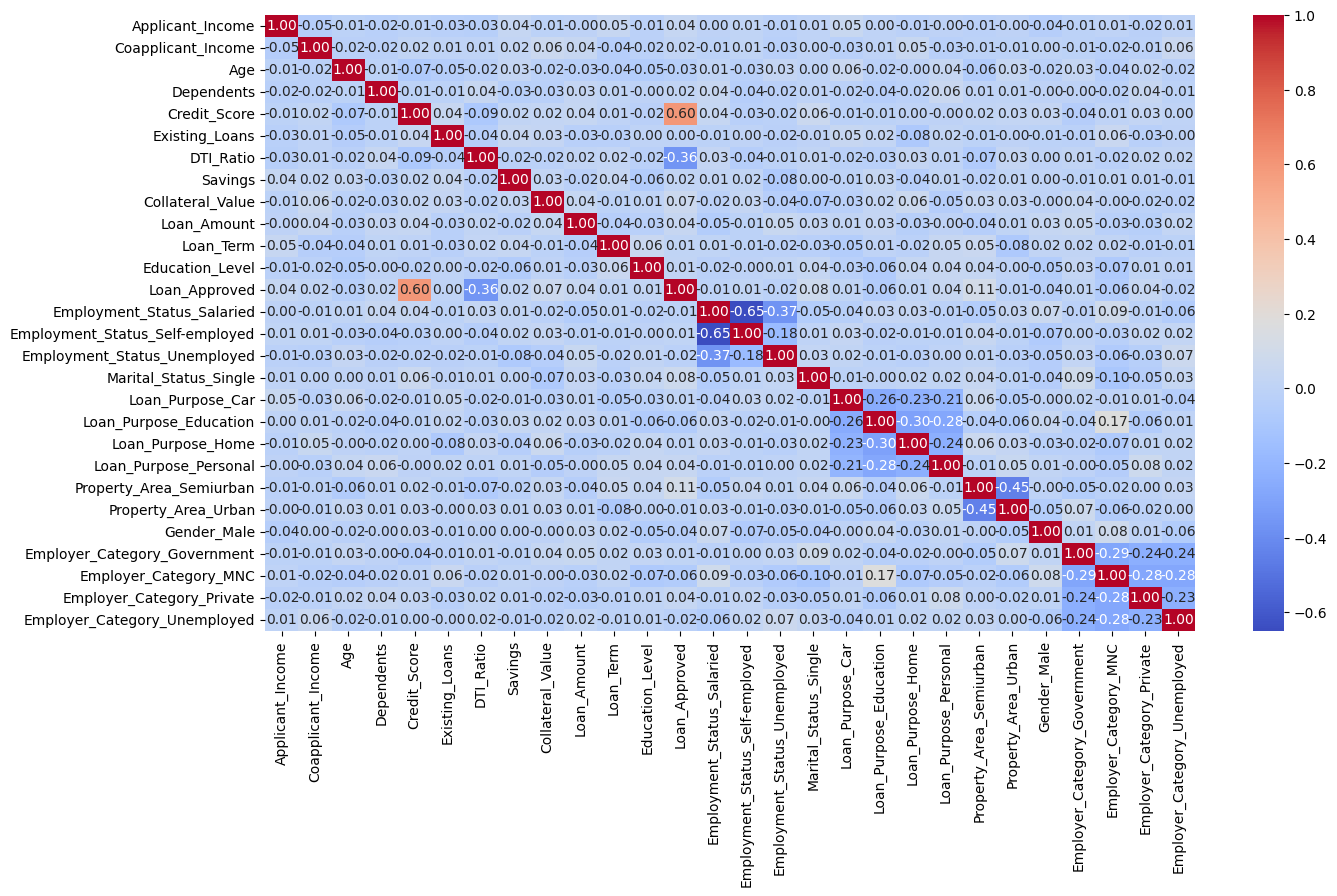

In [65]:
num_cols = df.select_dtypes(include="number")
corr_matrix = num_cols.corr()

plt.figure(figsize=(15, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)


In [66]:
num_cols.corr()["Loan_Approved"].sort_values(ascending=False)

,Loan_Approved
Loan_Approved,1.000000
Credit_Score,0.598407
Property_Area_Semiurban,0.106737
Marital_Status_Single,0.078186
Collateral_Value,0.070899
Loan_Amount,0.041740
Loan_Purpose_Personal,0.041205
Applicant_Income,0.037849
Employer_Category_Private,0.036569
Savings,0.018934


# Train-Test-Split + Feature Scaling

In [67]:
X = df.drop("Loan_Approved", axis=1)
y = df["Loan_Approved"]

In [68]:
y.head()

,Loan_Approved
0,0
1,0
2,1
3,0
4,0


In [69]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [70]:
X_test.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
521,6782.0,3459.0,46.0,2.0,663.0,4.0,0.41,19123.0,14356.0,8718.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
737,17660.0,9344.0,33.0,0.0,690.0,3.0,0.37,14114.0,19221.0,34574.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
740,6798.0,7334.0,25.0,2.0,686.0,1.0,0.41,1294.0,29597.0,33391.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
660,15157.0,8404.0,42.0,1.0,576.0,4.0,0.12,13468.0,28723.0,12821.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
411,16166.0,2768.0,44.0,2.0,603.0,4.0,0.35,7057.0,5984.0,19699.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [71]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [72]:
X_test_scaled

array([[-0.79746562, -0.5523758 ,  0.51610379, ...,  1.72629647,
        -0.48235427, -0.48235427],
       [ 1.37248904,  1.56217022, -0.70321782, ..., -0.57927478,
        -0.48235427,  2.07316503],
       [-0.79427393,  0.83995484, -1.45356958, ...,  1.72629647,
        -0.48235427, -0.48235427],
       ...,
       [-1.43799922, -0.53333231, -0.23424797, ..., -0.57927478,
         2.07316503, -0.48235427],
       [-0.25627359,  0.48495544, -1.35977561, ..., -0.57927478,
        -0.48235427, -0.48235427],
       [ 0.35513578,  1.26537922, -0.60942385, ..., -0.57927478,
        -0.48235427, -0.48235427]])

# Train & Evaluate Models

In [73]:
# Logistic regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)

y_pred = log_model.predict(X_test_scaled)

# Evaluation
print("Logistic Regression Model")
print("Precision: ", precision_score(y_test, y_pred))
print("Recall: ", recall_score(y_test, y_pred))
print("F1 score: ", f1_score(y_test, y_pred))
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("CM: ", confusion_matrix(y_test, y_pred))

Logistic Regression Model
Precision:  0.7468354430379747
Recall:  0.8309859154929577
F1 score:  0.7866666666666666
Accuracy:  0.84
CM:  [[109  20]
 [ 12  59]]


In [74]:
# KNN

from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

y_pred = knn_model.predict(X_test_scaled)

# Evaluation
print("KNN Model")
print("Precision: ", precision_score(y_test, y_pred))
print("Recall: ", recall_score(y_test, y_pred))
print("F1 score: ", f1_score(y_test, y_pred))
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("CM: ", confusion_matrix(y_test, y_pred))

KNN Model
Precision:  0.6
Recall:  0.5070422535211268
F1 score:  0.549618320610687
Accuracy:  0.705
CM:  [[105  24]
 [ 35  36]]


In [75]:
# Naive Bayes

from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

y_pred = nb_model.predict(X_test_scaled)

# Evaluation
print("Naive Bayes Model")
print("Precision: ", precision_score(y_test, y_pred))
print("Recall: ", recall_score(y_test, y_pred))
print("F1 score: ", f1_score(y_test, y_pred))
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("CM: ", confusion_matrix(y_test, y_pred))

Naive Bayes Model
Precision:  0.7037037037037037
Recall:  0.8028169014084507
F1 score:  0.75
Accuracy:  0.81
CM:  [[105  24]
 [ 14  57]]


## Best Model on the basis of Precision and recall=> Logistic Regression

# Feature Engineering

In [76]:
# Add or Tranform features
df["DTI_Ratio_sq"] = df["DTI_Ratio"] ** 2
df["Credit_Score_sq"] = df["Credit_Score"] ** 2

# df["Applicant_Income_log"] = np.log1p(df["Applicant_Income"])

X = df.drop(columns=["Loan_Approved", "Credit_Score", "DTI_Ratio"])
y = df["Loan_Approved"]

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [77]:
X_train.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Existing_Loans,Savings,Collateral_Value,Loan_Amount,Loan_Term,Education_Level,...,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed,DTI_Ratio_sq,Credit_Score_sq
29,9967.0,619.0,45.0,0.0,1.0,13142.0,15861.0,8266.0,60.0,1,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0841,350464.0
535,14528.0,4445.0,35.0,3.0,4.0,19940.0,42693.0,20276.0,84.0,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0900,505521.0
695,15108.0,5826.0,36.0,0.0,3.0,15150.0,27800.0,3260.0,36.0,0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.1521,442225.0
557,5899.0,759.0,36.0,3.0,4.0,17049.0,31886.0,8065.0,60.0,0,...,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.2916,421201.0
836,3503.0,4665.0,57.0,3.0,0.0,4689.0,35214.0,1848.0,36.0,1,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.3600,302500.0


In [78]:
# Logistic regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)

y_pred = log_model.predict(X_test_scaled)

# Evaluation
print("Logistic Regression Model")
print("Precision: ", precision_score(y_test, y_pred))
print("Recall: ", recall_score(y_test, y_pred))
print("F1 score: ", f1_score(y_test, y_pred))
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("CM: ", confusion_matrix(y_test, y_pred))

Logistic Regression Model
Precision:  0.7402597402597403
Recall:  0.8028169014084507
F1 score:  0.7702702702702703
Accuracy:  0.83
CM:  [[109  20]
 [ 14  57]]


In [79]:
# KNN

from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

y_pred = knn_model.predict(X_test_scaled)

# Evaluation
print("KNN Model")
print("Precision: ", precision_score(y_test, y_pred))
print("Recall: ", recall_score(y_test, y_pred))
print("F1 score: ", f1_score(y_test, y_pred))
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("CM: ", confusion_matrix(y_test, y_pred))

KNN Model
Precision:  0.5789473684210527
Recall:  0.4647887323943662
F1 score:  0.515625
Accuracy:  0.69
CM:  [[105  24]
 [ 38  33]]


In [80]:
# Naive Bayes

from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

y_pred = nb_model.predict(X_test_scaled)

# Evaluation
print("Naive Bayes Model")
print("Precision: ", precision_score(y_test, y_pred))
print("Recall: ", recall_score(y_test, y_pred))
print("F1 score: ", f1_score(y_test, y_pred))
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("CM: ", confusion_matrix(y_test, y_pred))

Naive Bayes Model
Precision:  0.7012987012987013
Recall:  0.7605633802816901
F1 score:  0.7297297297297297
Accuracy:  0.8
CM:  [[106  23]
 [ 17  54]]


## Feature Importance

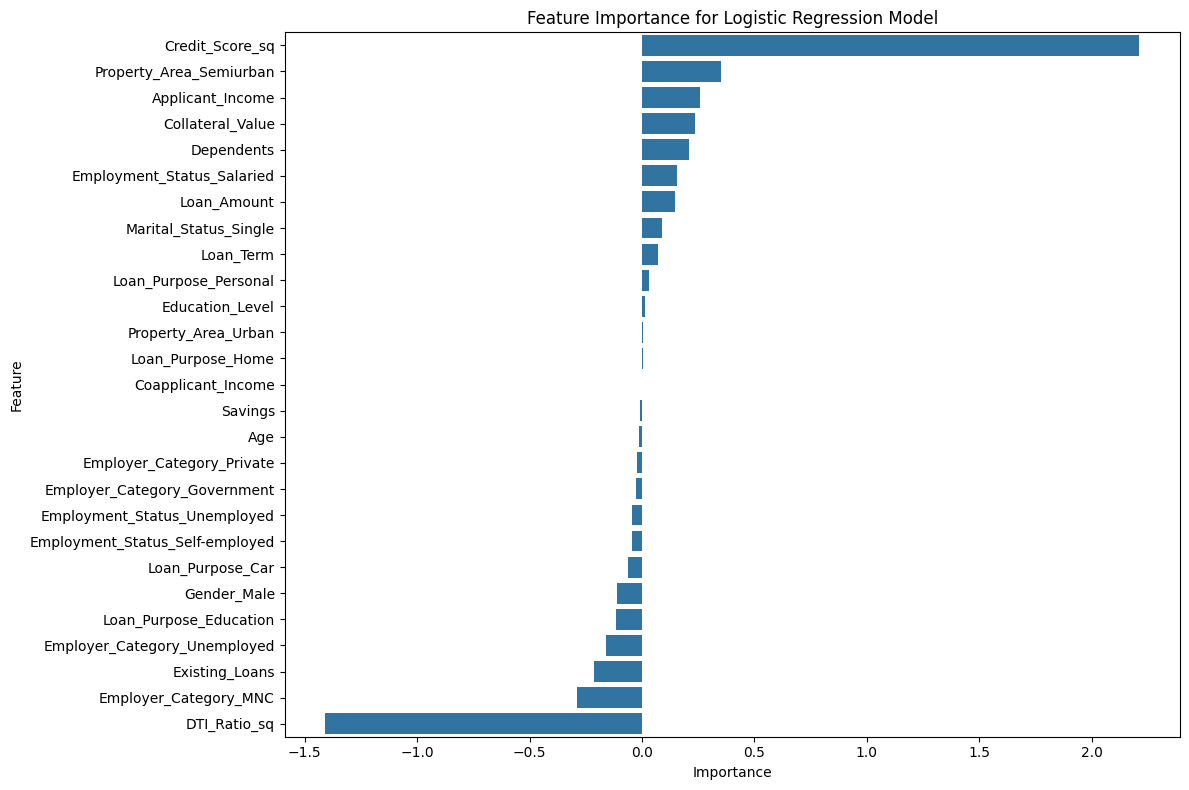

In [81]:
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': log_model.coef_[0]
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=feature_importance)
plt.title('Feature Importance for Logistic Regression Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## ROC AUC Graph

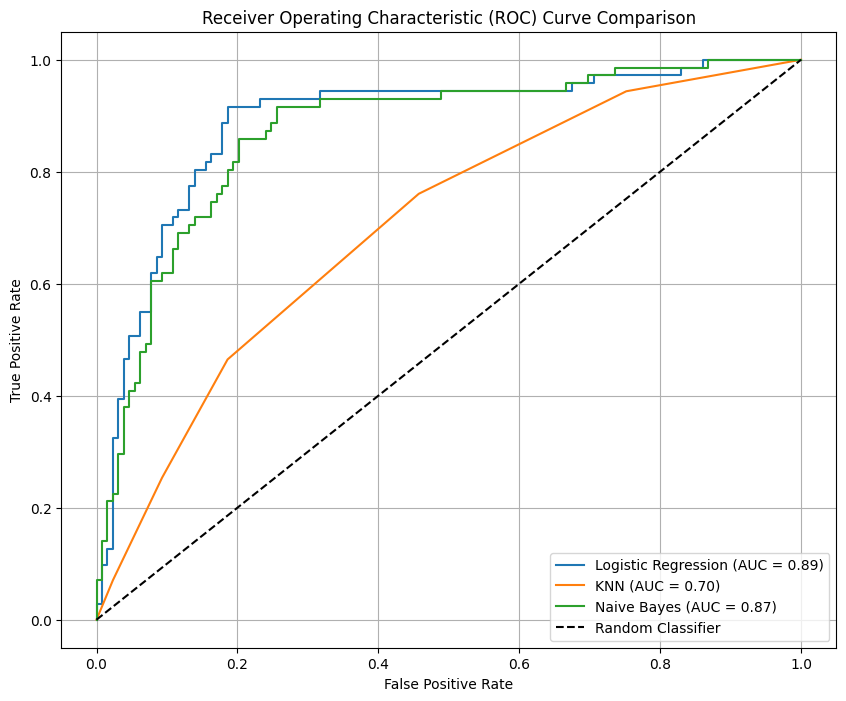

In [82]:
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(10, 8))

# Logistic Regression ROC Curve
y_pred_proba_log = log_model.predict_proba(X_test_scaled)[:, 1]
fpr_log, tpr_log, _ = roc_curve(y_test, y_pred_proba_log)
auc_log = roc_auc_score(y_test, y_pred_proba_log)
plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = {auc_log:.2f})')

# KNN ROC Curve
y_pred_proba_knn = knn_model.predict_proba(X_test_scaled)[:, 1]
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_pred_proba_knn)
auc_knn = roc_auc_score(y_test, y_pred_proba_knn)
plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {auc_knn:.2f})')

# Naive Bayes ROC Curve
y_pred_proba_nb = nb_model.predict_proba(X_test_scaled)[:, 1]
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_pred_proba_nb)
auc_nb = roc_auc_score(y_test, y_pred_proba_nb)
plt.plot(fpr_nb, tpr_nb, label=f'Naive Bayes (AUC = {auc_nb:.2f})')

# Plot settings
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve Comparison')
plt.legend()
plt.grid(True)
plt.show()

## Classification Report

In [83]:
from sklearn.metrics import classification_report

print('--- Logistic Regression Classification Report ---')
y_pred_log = log_model.predict(X_test_scaled)
print(classification_report(y_test, y_pred_log))

print('\n--- KNN Classification Report ---')
y_pred_knn = knn_model.predict(X_test_scaled)
print(classification_report(y_test, y_pred_knn))

print('\n--- Naive Bayes Classification Report ---')
y_pred_nb = nb_model.predict(X_test_scaled)
print(classification_report(y_test, y_pred_nb))

--- Logistic Regression Classification Report ---
              precision    recall  f1-score   support

           0       0.89      0.84      0.87       129
           1       0.74      0.80      0.77        71

    accuracy                           0.83       200
   macro avg       0.81      0.82      0.82       200
weighted avg       0.83      0.83      0.83       200


--- KNN Classification Report ---
              precision    recall  f1-score   support

           0       0.73      0.81      0.77       129
           1       0.58      0.46      0.52        71

    accuracy                           0.69       200
   macro avg       0.66      0.64      0.64       200
weighted avg       0.68      0.69      0.68       200


--- Naive Bayes Classification Report ---
              precision    recall  f1-score   support

           0       0.86      0.82      0.84       129
           1       0.70      0.76      0.73        71

    accuracy                           0.80       200


##Logistic regression give best result for loan approval model